In [1]:
import sys
from tqdm import tqdm

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.processor import Processor
from main import init_parser, update_parameters

In [2]:
parser = init_parser()
evaluation_case = 'CV'
# (T2: 12 Apr) Model
sys.argv = ['notebook_cell', '--config', './config/ntu_ablation/ntu60_angle-view.yaml', '-e']
args = parser.parse_args()
args = update_parameters(parser, args)  # cmd > yaml > default

p = Processor(args)

[ 2026-04-25 11:56:04,598 ] Saving folder path: ./workdir/ntu_angle/temp
[ 2026-04-25 11:56:04,599 ] 
[ 2026-04-25 11:56:04,600 ] Saving model name: Trans-GCN_ntu60
[ 2026-04-25 11:56:04,766 ] Using aligned data.
[ 2026-04-25 11:57:25,133 ] Dataset: ntu60
[ 2026-04-25 11:57:25,135 ] Batch size: train-64, eval-128
[ 2026-04-25 11:57:25,136 ] Data shape (branch, channel, frame, joint, person): [1, 3, 64, 25, 2]
[ 2026-04-25 11:57:25,136 ] Number of action classes: 60
[ 2026-04-25 11:57:25,162 ] Model: Trans-GCN {'use_att': True, 'kernel_size': [3, 2], 'dilations': [2, 3], 'reduct_ratio': 2, 'use_gcn': False, 'so2_arg': {'heads': 8, 'angle_partitions': 6, 'rot_one_axis': False}}
[ 2026-04-25 11:57:26,578 ] Model profile: 0.57G FLOPs and 0.74M Parameters
[ 2026-04-25 11:57:28,174 ] Optimizer: SGD {'lr': 0.1, 'momentum': 0.9, 'nesterov': True, 'weight_decay': 0.0002}
[ 2026-04-25 11:57:28,175 ] LR_Scheduler: step {'max_epoch': 100, 'warm_up': 0, 'step_lr': [80, 90]}
[ 2026-04-25 11:57:28,17

In [ ]:

def extract_tk(model):

    if isinstance(model, torch.nn.DataParallel):
        model = model.module

    tk_first_layer = []
    tk_other_layers = []

    def get_angles(angles):
        # angles (x,y,z) by 6 → (3, 6)
        dim, n = angles.shape
        modulus = torch.pi/n
        prev_mod = torch.tensor(list(map(lambda k: torch.pi*(k)/n, range(n)))).to(angles.device)

        offset = (0.5 * (torch.atan2(
                torch.sin(angles),
                torch.cos(angles)
            ) + torch.pi))* (modulus / torch.pi) # range: [0, modulus)
       
        return prev_mod + offset

    def process_gcn(gcn_module):
        # gcn_module has t_k: {'x','y','z'} each of shape [6]
        tk = gcn_module.t_k
        
        # stack (x,y,z) → (3, 6)
        tk = torch.stack([tk['x'], tk['y'], tk['z']], dim=0)

        return get_angles(tk)

    # --- input branches ---
    for branch in model.input_branches:
        for layer in branch.layers:
            scn = layer.scn

            if hasattr(scn, 'gcn'):
                if isinstance(scn.gcn, torch.nn.ModuleList):
                    # multi-head (8 heads)
                    heads = [process_gcn(g) for g in scn.gcn]
                    heads = torch.stack(heads, dim=0)   # (8, 3, 6)
                    tk_other_layers.append(heads)
                else:
                    # single head
                    heads = process_gcn(scn.gcn)  # (3, 6)
                    tk_first_layer.append(heads)

    # --- main stream ---
    for layer in model.main_stream:
        scn = layer.scn

        if isinstance(scn.gcn, torch.nn.ModuleList):
            heads = [process_gcn(g) for g in scn.gcn]
            heads = torch.stack(heads, dim=0)  # (8, 3, 6)
        else:
            heads = process_gcn(scn.gcn).unsqueeze(0)

        tk_other_layers.append(heads)

    detach = lambda x : x.cpu().detach().numpy()

    # Final tensor: (3, 6) , (5, num_heads, 3, 6)
    return detach(torch.tensor(tk_first_layer[0])), detach(torch.stack(tk_other_layers, dim=0))

In [27]:
first, others = extract_tk(p.model)

In [28]:
first

array([[0.31691208, 0.80764186, 1.3141367 , 1.8843722 , 2.3185358 ,
        2.8659492 ],
       [0.13490203, 0.8172052 , 1.2233629 , 1.7856747 , 2.281837  ,
        2.874939  ],
       [0.24550693, 0.7049285 , 1.3441982 , 1.8548722 , 2.321095  ,
        2.837235  ]], dtype=float32)

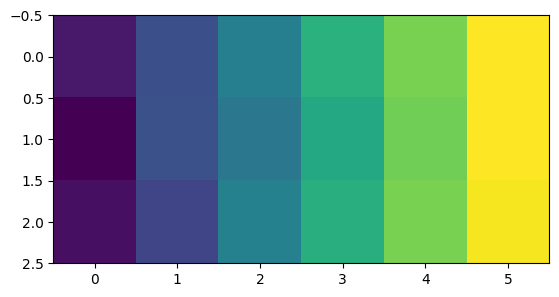

In [29]:
plt.imshow(first)

In [49]:
def plot_tk_heatmap(tk, mode=2, normalize=False):
    """
    tk: numpy array of shape (L, H, 3, 6)

    mode:
        1 → [layers, axis*heads, 6]
        2 → [axis, layers*heads, 6]
        3 → [heads, axis*layers, 6]

    normalize: whether to z-score normalize before plotting
    """

    assert tk.ndim == 4, "Expected shape (L, H, 3, 6)"
    L, H, A, K = tk.shape
    assert A == 3 and K == 6, "Expected (L, H, 3, 6)"

    axis_names = ['x', 'y', 'z']

    # ---------- reshape depending on mode ----------
    if mode == 1:
        # (L, H, 3, 6) → (L, 3, H, 6) → (L, 3*H, 6)
        tk_plot = np.transpose(tk, (0, 2, 1, 3)).reshape(L, 3*H, K)
        titles = [f'Layer {i}' for i in range(L)]
        n_subplots = L
        xlabel = 'Angle partition'
        ylabel = 'Axis × Head'

    elif mode == 2:
        # (L, H, 3, 6) → (3, L, H, 6) → (3, L*H, 6)
        tk_plot = np.transpose(tk, (2, 0, 1, 3)).reshape(3, L*H, K)
        titles = [f'Axis: {axis_names[i]}' for i in range(3)]
        n_subplots = 3
        xlabel = 'Angle partition'
        ylabel = 'Layer × Head'

    elif mode == 3:
        # (L, H, 3, 6) → (H, 3, L, 6) → (H, 3*L, 6)
        tk_plot = np.transpose(tk, (1, 2, 0, 3)).reshape(H, 3*L, K)
        titles = [f'Head {i}' for i in range(H)]
        n_subplots = H
        xlabel = 'Angle partition'
        ylabel = 'Axis × Layer'

    else:
        raise ValueError("mode must be 1, 2, or 3")

    # ---------- optional normalization ----------
    if normalize:
        tk_plot = (tk_plot - tk_plot.mean()) / (tk_plot.std() + 1e-6)

    # ---------- plotting ----------
    fig, axes = plt.subplots(1, n_subplots, figsize=(4*n_subplots, 4))

    # handle case when n_subplots == 1
    if n_subplots == 1:
        axes = [axes]

    for i in range(n_subplots):
        im = axes[i].imshow(tk_plot[i], aspect='auto')
        axes[i].set_title(titles[i])
        axes[i].set_xlabel(xlabel)
        axes[i].set_ylabel(ylabel)
        fig.colorbar(im, ax=axes[i])

    plt.tight_layout()
    plt.savefig(f'zz_ablatn_images/t_k-angles_mode{mode}.png')
    plt.show()

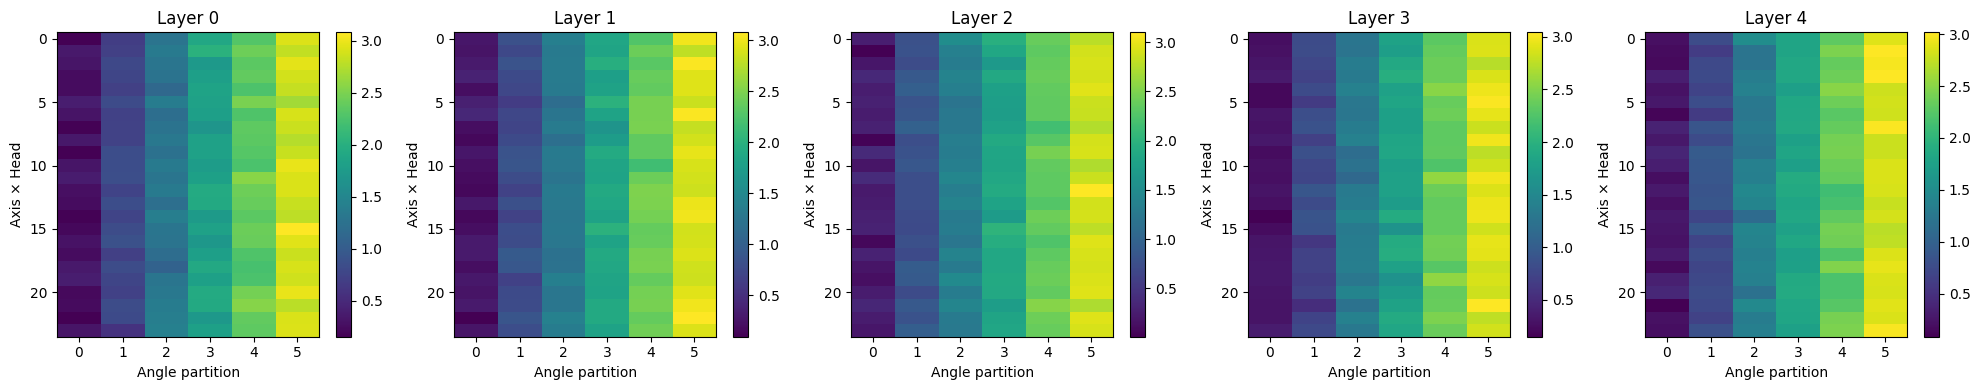

In [50]:
plot_tk_heatmap(others, mode=1, normalize=False)

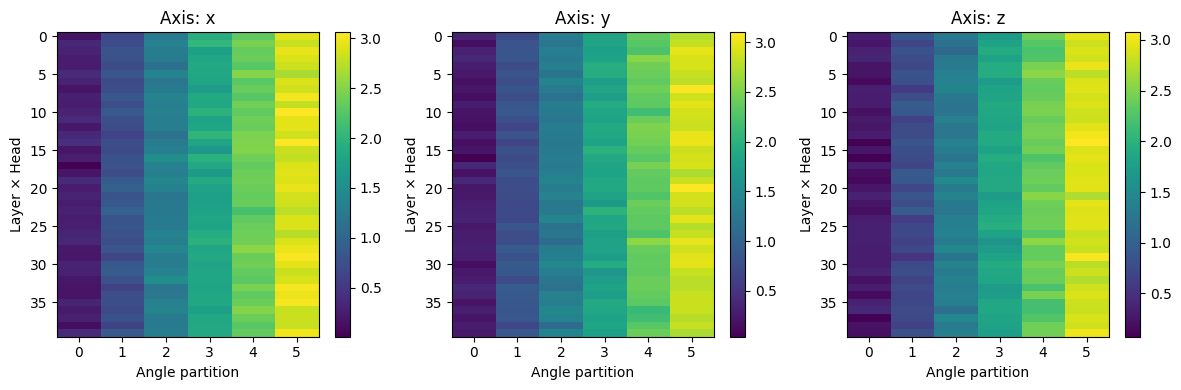

In [51]:
plot_tk_heatmap(others, mode=2, normalize=False)

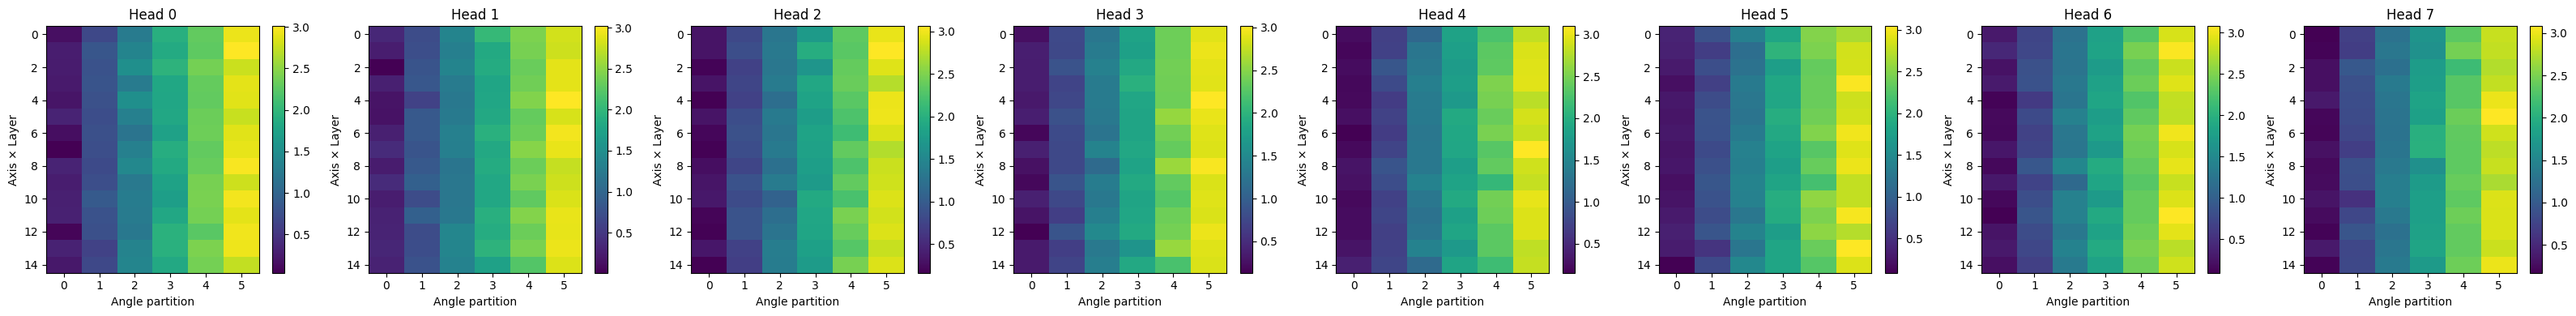

In [52]:
plot_tk_heatmap(others, mode=3, normalize=False)